# 🌲 Tree-Based Algorithms for Regression
## A Complete Machine Learning Tutorial Using the Insurance Dataset

---

Welcome to this hands-on lesson on tree-based machine learning algorithms. By the end of this notebook, you will understand how decision trees split data, why random forests outperform a single tree, and how gradient boosting algorithms like XGBoost, LightGBM, and CatBoost push performance even further.

We will use the **Medical Cost Personal Dataset** (`insurance.csv`) throughout — a real-world dataset where we predict insurance charges based on patient characteristics.

**Dataset Features:**
- `age`: Age of the primary beneficiary
- `sex`: Gender (male/female)
- `bmi`: Body mass index
- `children`: Number of dependents
- `smoker`: Smoking status (yes/no)
- `region`: Residential region in the US
- `charges`: 🎯 **Target** — Individual medical costs billed by insurance

---

In [4]:
from google.colab import files

files.upload()

Saving insurance.csv to insurance.csv


{'insurance.csv': b'age,sex,bmi,children,smoker,region,charges\r\n19,female,27.9,0,yes,southwest,16884.924\r\n18,male,33.77,1,no,southeast,1725.5523\r\n28,male,33,3,no,southeast,4449.462\r\n33,male,22.705,0,no,northwest,21984.47061\r\n32,male,28.88,0,no,northwest,3866.8552\r\n31,female,25.74,0,no,southeast,3756.6216\r\n46,female,33.44,1,no,southeast,8240.5896\r\n37,female,27.74,3,no,northwest,7281.5056\r\n37,male,29.83,2,no,northeast,6406.4107\r\n60,female,25.84,0,no,northwest,28923.13692\r\n25,male,26.22,0,no,northeast,2721.3208\r\n62,female,26.29,0,yes,southeast,27808.7251\r\n23,male,34.4,0,no,southwest,1826.843\r\n56,female,39.82,0,no,southeast,11090.7178\r\n27,male,42.13,0,yes,southeast,39611.7577\r\n19,male,24.6,1,no,southwest,1837.237\r\n52,female,30.78,1,no,northeast,10797.3362\r\n23,male,23.845,0,no,northeast,2395.17155\r\n56,male,40.3,0,no,southwest,10602.385\r\n30,male,35.3,0,yes,southwest,36837.467\r\n60,female,36.005,0,no,northeast,13228.84695\r\n30,female,32.4,1,no,southwe

## 📦 Step 1: Imports and Setup

We import all the libraries we need. The try/except blocks for XGBoost, LightGBM, and CatBoost handle environments where those packages may not be installed. If they're missing, run:

```bash
pip install xgboost lightgbm catboost
```

In [5]:
!pip install xgboost lightgbm catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.6 MB/s eta 0:00:00


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

# Core sklearn tools
from sklearn.model_selection import train_test_split, cross_val_score, learning_curve
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeRegressor, plot_tree, export_text
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Gradient boosting libraries (install if missing)
try:
    import xgboost as xgb
    XGBOOST_AVAILABLE = True
    print("✅ XGBoost available:", xgb.__version__)
except ImportError:
    XGBOOST_AVAILABLE = False
    print("⚠️  XGBoost not installed. Run: pip install xgboost")

try:
    import lightgbm as lgb
    LIGHTGBM_AVAILABLE = True
    print("✅ LightGBM available:", lgb.__version__)
except ImportError:
    LIGHTGBM_AVAILABLE = False
    print("⚠️  LightGBM not installed. Run: pip install lightgbm")

try:
    from catboost import CatBoostRegressor
    CATBOOST_AVAILABLE = True
    print("✅ CatBoost available")
except ImportError:
    CATBOOST_AVAILABLE = False
    print("⚠️  CatBoost not installed. Run: pip install catboost")

# Plotting style
plt.style.use('seaborn-v0_8-whitegrid')
COLORS = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63', '#9C27B0', '#00BCD4']
print("\n✅ All core imports successful!")

✅ XGBoost available: 3.2.0
✅ LightGBM available: 4.6.0
✅ CatBoost available

✅ All core imports successful!


## 📊 Step 2: Load and Explore the Data

Before building any model, we must understand what we're working with. Exploratory Data Analysis (EDA) reveals the shape, distributions, and relationships in the data — all of which inform our modeling choices.

In [7]:
# Load the dataset
#df = pd.read_csv('..data/insurance.csv')
df = pd.read_csv('insurance.csv')

print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Dataset shape: (1338, 7)

First 5 rows:


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [8]:
print("Data types and non-null counts:")
df.info()

print("\nDescriptive statistics:")
df.describe()

Data types and non-null counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB

Descriptive statistics:


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


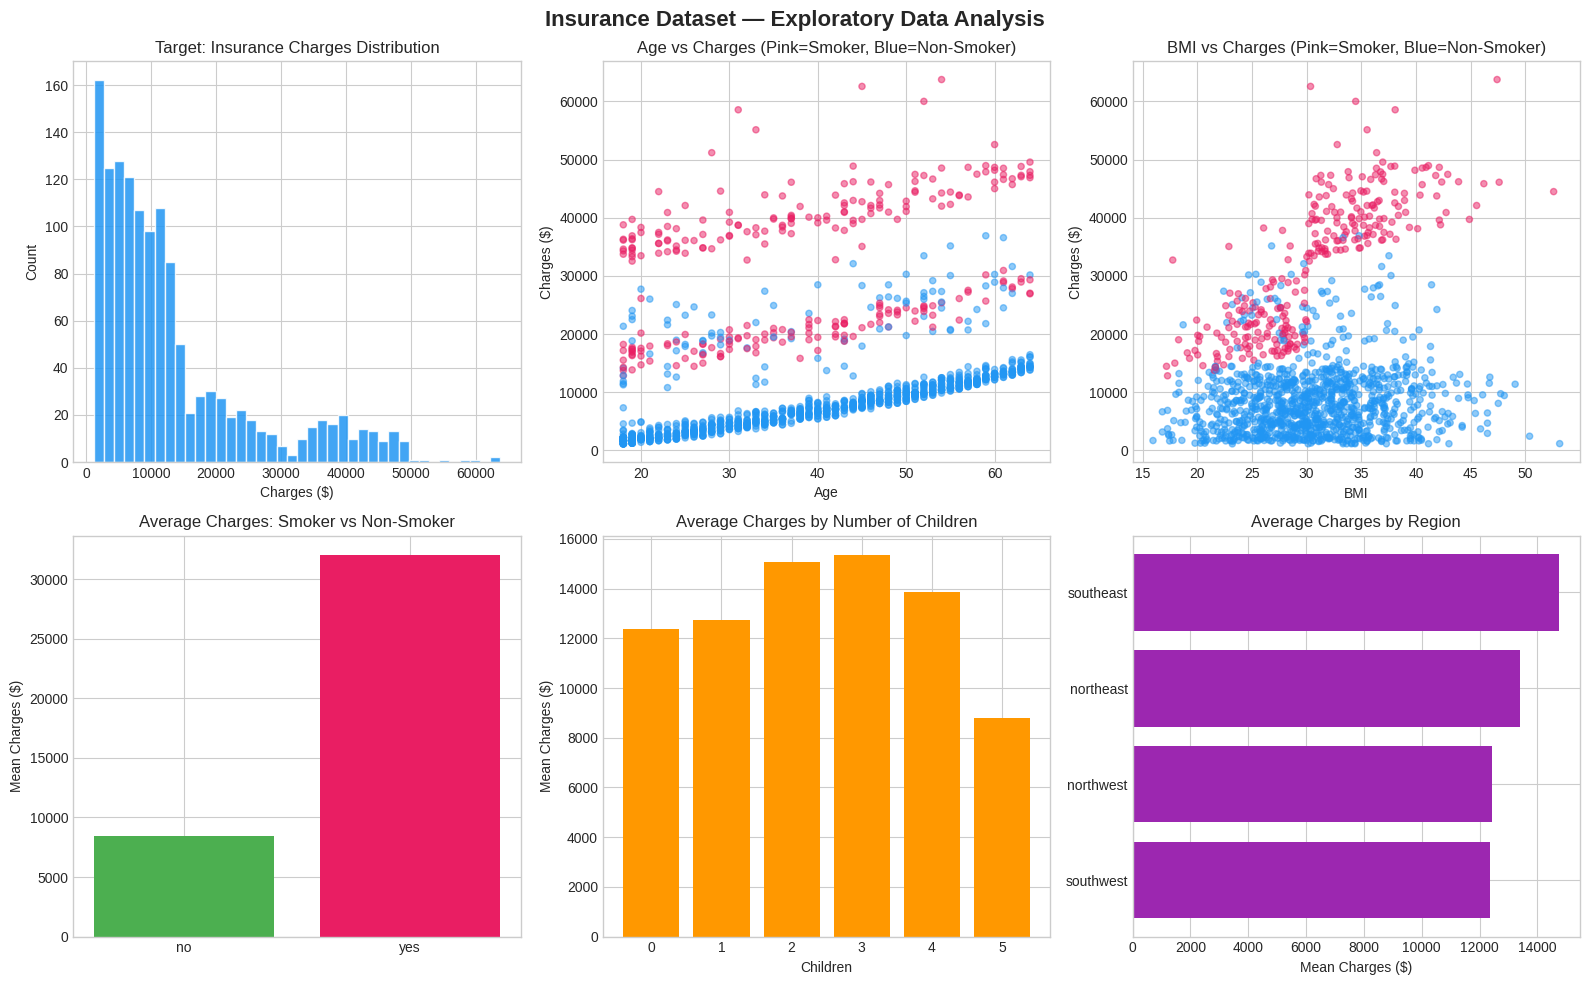


Key observation: Smoker status and BMI are strong predictors of insurance charges.


In [ ]:
# Visualize distributions and relationships
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Insurance Dataset — Exploratory Data Analysis', fontsize=16, fontweight='bold')

# Charges distribution
axes[0,0].hist(df['charges'], bins=40, color=COLORS[0], edgecolor='white', alpha=0.85)
axes[0,0].set_title('Target: Insurance Charges Distribution')
axes[0,0].set_xlabel('Charges ($)')
axes[0,0].set_ylabel('Count')

# Age vs Charges
smoker_colors = df['smoker'].map({'yes': '#E91E63', 'no': '#2196F3'})
axes[0,1].scatter(df['age'], df['charges'], c=smoker_colors, alpha=0.5, s=20)
axes[0,1].set_title('Age vs Charges (Pink=Smoker, Blue=Non-Smoker)')
axes[0,1].set_xlabel('Age')
axes[0,1].set_ylabel('Charges ($)')

# BMI vs Charges
axes[0,2].scatter(df['bmi'], df['charges'], c=smoker_colors, alpha=0.5, s=20)
axes[0,2].set_title('BMI vs Charges (Pink=Smoker, Blue=Non-Smoker)')
axes[0,2].set_xlabel('BMI')
axes[0,2].set_ylabel('Charges ($)')

# Smoker vs Charges
smoker_means = df.groupby('smoker')['charges'].mean()
axes[1,0].bar(smoker_means.index, smoker_means.values, color=[COLORS[1], COLORS[3]])
axes[1,0].set_title('Average Charges: Smoker vs Non-Smoker')
axes[1,0].set_ylabel('Mean Charges ($)')

# Children vs Charges
children_means = df.groupby('children')['charges'].mean()
axes[1,1].bar(children_means.index.astype(str), children_means.values, color=COLORS[2])
axes[1,1].set_title('Average Charges by Number of Children')
axes[1,1].set_xlabel('Children')
axes[1,1].set_ylabel('Mean Charges ($)')

# Region vs Charges
region_means = df.groupby('region')['charges'].mean().sort_values()
axes[1,2].barh(region_means.index, region_means.values, color=COLORS[4])
axes[1,2].set_title('Average Charges by Region')
axes[1,2].set_xlabel('Mean Charges ($)')

plt.tight_layout()
plt.savefig('eda_insurance.png', dpi=120, bbox_inches='tight')
plt.show()

print("\nKey observation: Smoker status and BMI are strong predictors of insurance charges.")

## 🔧 Step 3: Preprocessing

Tree-based algorithms are remarkably flexible — they can handle a mix of numerical and categorical features, and they don't require feature scaling (unlike linear models or neural networks). However, we still need to encode string columns into numbers since scikit-learn expects numerical arrays.

In [ ]:
# Encode categorical columns
df_encoded = df.copy()
le = LabelEncoder()

for col in ['sex', 'smoker', 'region']:
    df_encoded[col] = le.fit_transform(df[col])
    print(f"{col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")

# Separate features and target
X = df_encoded.drop('charges', axis=1)
y = df_encoded['charges']

# Train/test split: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\nTraining samples: {len(X_train)}, Test samples: {len(X_test)}")
print(f"Features: {list(X.columns)}")
print(f"Target — Mean: ${y.mean():,.0f}, Std: ${y.std():,.0f}")

---

# 🌳 Part A: Decision Trees

## How Decision Trees Work

A decision tree learns by repeatedly asking **yes/no questions** about features. At each internal node, the algorithm searches all possible split points across all features and chooses the one that reduces prediction error the most.

For regression tasks, the quality of a split is measured using **Mean Squared Error (MSE)**:

$$\text{MSE}_{split} = \frac{1}{n_L}\sum_{i \in L}(y_i - \bar{y}_L)^2 + \frac{1}{n_R}\sum_{i \in R}(y_i - \bar{y}_R)^2$$

Where $L$ and $R$ are the left and right subsets after the split.

**The algorithm:**
1. Start with all training data at the root node
2. Try every possible split on every feature
3. Choose the split that minimizes MSE the most
4. Recursively repeat on each child node
5. Stop when a stopping criterion is met (max depth, min samples, etc.)
6. At each leaf, the prediction = **average of all training samples in that leaf**

**Advantages:** Interpretable, handles mixed types, no scaling needed, captures non-linear patterns

**Limitations:** Prone to overfitting, high variance (different training sets → very different trees)

In [ ]:
# ---- Train a Decision Tree ----

dt_model = DecisionTreeRegressor(
    max_depth=4,          # Limit depth to prevent overfitting
    min_samples_split=20, # Node must have ≥20 samples to split
    min_samples_leaf=10,  # Each leaf must have ≥10 samples
    random_state=42
)
dt_model.fit(X_train, y_train)

# Evaluate
y_pred_dt = dt_model.predict(X_test)
mae_dt = mean_absolute_error(y_test, y_pred_dt)
r2_dt  = r2_score(y_test, y_pred_dt)

print("📊 Decision Tree Performance (max_depth=4):")
print(f"   MAE  = ${mae_dt:,.0f}")
print(f"   R²   = {r2_dt:.4f}")
print(f"   Tree nodes: {dt_model.tree_.node_count}")

In [ ]:
# Visualize the Decision Tree
fig, ax = plt.subplots(figsize=(22, 9))
plot_tree(
    dt_model,
    feature_names=X.columns.tolist(),
    filled=True,
    rounded=True,
    fontsize=8,
    ax=ax,
    impurity=False,
    precision=0
)
ax.set_title('Decision Tree Visualization (max_depth=4)\nEach leaf shows: predicted charge | sample count',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('decision_tree_viz.png', dpi=100, bbox_inches='tight')
plt.show()

print("\n📖 How to read this tree:")
print("  • Each box shows: the split condition, # samples, and mean value")
print("  • Darker color = higher predicted charge")
print("  • Follow TRUE (left) or FALSE (right) at each split")

In [ ]:
# Demonstrate Overfitting: Compare shallow vs deep trees
depths = [1, 2, 3, 4, 5, 7, 10, 15, 20, None]
train_scores, test_scores = [], []

for depth in depths:
    tree = DecisionTreeRegressor(max_depth=depth, random_state=42)
    tree.fit(X_train, y_train)
    train_scores.append(r2_score(y_train, tree.predict(X_train)))
    test_scores.append(r2_score(y_test, tree.predict(X_test)))

depth_labels = [str(d) if d is not None else 'None\n(full)' for d in depths]

plt.figure(figsize=(11, 5))
plt.plot(range(len(depths)), train_scores, 'o-', color=COLORS[0], linewidth=2, label='Train R²', markersize=8)
plt.plot(range(len(depths)), test_scores,  's-', color=COLORS[3], linewidth=2, label='Test R²',  markersize=8)
plt.xticks(range(len(depths)), depth_labels)
plt.xlabel('Max Tree Depth', fontsize=12)
plt.ylabel('R² Score', fontsize=12)
plt.title('Decision Tree: Depth vs Performance (Bias-Variance Tradeoff)', fontsize=13, fontweight='bold')
plt.legend(fontsize=12)
plt.axvspan(2.5, 5.5, alpha=0.1, color='green', label='Sweet spot')
plt.annotate('Sweet spot\n(good generalization)', xy=(4, 0.82), fontsize=10, color='green',
             bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.3))
plt.annotate('Overfitting →\nTrain high, Test low', xy=(7.5, 0.65), fontsize=10, color='red',
             bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.5))
plt.tight_layout()
plt.savefig('depth_vs_performance.png', dpi=120, bbox_inches='tight')
plt.show()

for i, (d, tr, te) in enumerate(zip(depth_labels, train_scores, test_scores)):
    gap = tr - te
    flag = " ← best generalization" if te == max(test_scores) else ""
    print(f"Depth {d:>5}: Train R²={tr:.3f}  Test R²={te:.3f}  Gap={gap:.3f}{flag}")

In [ ]:
# Feature Importance from Decision Tree
importances_dt = pd.Series(dt_model.feature_importances_, index=X.columns).sort_values(ascending=True)

plt.figure(figsize=(8, 5))
importances_dt.plot(kind='barh', color=COLORS[0])
plt.title('Decision Tree: Feature Importances', fontsize=13, fontweight='bold')
plt.xlabel('Importance (fraction of MSE reduction)')
plt.tight_layout()
plt.savefig('dt_importance.png', dpi=120, bbox_inches='tight')
plt.show()

print("\n🔍 Interpretation:")
print("'smoker' drives the first and most important split.")
print("Smokers cluster at much higher charges — the tree learns this immediately.")

---

# 🌲🌲🌲 Part B: Random Forests — Ensemble Learning

## From One Tree to a Forest

A single decision tree has a critical flaw: **high variance**. Small changes in training data produce very different trees. Random forests solve this by training **many trees** and averaging their predictions.

### Two Key Ideas Behind Random Forests:

**1. Bagging (Bootstrap Aggregating)**  
Each tree is trained on a **different bootstrap sample** — a random sample *with replacement* from the training data. This means each tree sees roughly 63% of the data, with the rest used as out-of-bag validation.

**2. Random Feature Subsets**  
At each split, only a **random subset of features** is considered (typically $\sqrt{p}$ for classification, $p/3$ for regression). This *decorrelates* the trees — if one feature dominates, not all trees will use it the same way.

**Final prediction:** Average of all trees' predictions
$$\hat{y} = \frac{1}{B}\sum_{b=1}^{B} T_b(x)$$

**Why it works (Bias-Variance Decomposition):**
- Individual trees have **low bias** (deep trees fit well) but **high variance**
- Averaging reduces variance without increasing bias
- Result: much more stable and accurate predictions

In [ ]:
# ---- Train a Random Forest ----

rf_model = RandomForestRegressor(
    n_estimators=200,      # Number of trees — more is generally better (up to a point)
    max_depth=None,        # Let trees grow deep; bagging prevents overfitting
    max_features='sqrt',   # At each split, consider sqrt(n_features) candidates
    min_samples_leaf=3,    # Minimum samples per leaf
    oob_score=True,        # Estimate test performance using out-of-bag samples
    n_jobs=-1,             # Use all CPU cores
    random_state=42
)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf  = r2_score(y_test, y_pred_rf)

print("📊 Random Forest Performance (200 trees):")
print(f"   MAE       = ${mae_rf:,.0f}")
print(f"   R² (test) = {r2_rf:.4f}")
print(f"   OOB R²    = {rf_model.oob_score_:.4f}  ← Free validation estimate from bagging!")

In [ ]:
# How performance grows with number of trees
n_trees_list = [1, 5, 10, 20, 50, 100, 200, 500]
rf_test_r2   = []
rf_train_r2  = []

for n in n_trees_list:
    rf_temp = RandomForestRegressor(n_estimators=n, random_state=42, n_jobs=-1)
    rf_temp.fit(X_train, y_train)
    rf_train_r2.append(r2_score(y_train, rf_temp.predict(X_train)))
    rf_test_r2.append(r2_score(y_test, rf_temp.predict(X_test)))

plt.figure(figsize=(10, 5))
plt.semilogx(n_trees_list, rf_train_r2, 'o-', color=COLORS[0], linewidth=2, label='Train R²', markersize=8)
plt.semilogx(n_trees_list, rf_test_r2,  's-', color=COLORS[1], linewidth=2, label='Test R²',  markersize=8)
plt.xlabel('Number of Trees (log scale)', fontsize=12)
plt.ylabel('R² Score', fontsize=12)
plt.title('Random Forest: Performance vs Number of Trees', fontsize=13, fontweight='bold')
plt.legend(fontsize=12)
plt.xticks(n_trees_list, n_trees_list)
plt.tight_layout()
plt.savefig('rf_n_trees.png', dpi=120, bbox_inches='tight')
plt.show()

print("Key insight: After ~100 trees, performance plateaus.")
print("Adding more trees improves stability but rarely accuracy.")

In [ ]:
# Random Forest Feature Importances
importances_rf = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=True)

plt.figure(figsize=(8, 5))
importances_rf.plot(kind='barh', color=COLORS[1])
plt.title('Random Forest: Feature Importances (Mean Decrease in Impurity)', fontsize=12, fontweight='bold')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('rf_importance.png', dpi=120, bbox_inches='tight')
plt.show()

print("\n📊 DT vs RF Feature Importances:")
comparison = pd.DataFrame({
    'Decision Tree': dt_model.feature_importances_,
    'Random Forest': rf_model.feature_importances_
}, index=X.columns).sort_values('Random Forest', ascending=False)
print(comparison.round(4))

---

# ⚡ Part C: Gradient Boosting — XGBoost, LightGBM, CatBoost

## The Gradient Boosting Idea

While Random Forests train trees **in parallel** (independently), Gradient Boosting trains trees **sequentially** — each new tree learns to correct the errors of all previous trees.

### The Core Algorithm:
1. Start with a simple prediction (e.g., the mean of all targets)
2. Calculate **residuals** = (actual − current prediction)
3. Train a new small tree to predict those residuals
4. Update predictions by adding the new tree's output (scaled by learning rate η)
5. Repeat steps 2–4 for T rounds

$$F_m(x) = F_{m-1}(x) + \eta \cdot h_m(x)$$

Where $h_m$ is the new tree fitted to residuals of $F_{m-1}$.

### XGBoost, LightGBM, CatBoost — Key Differences:

| Feature | XGBoost | LightGBM | CatBoost |
|---------|---------|----------|----------|
| Tree growth | Level-wise | Leaf-wise | Symmetric (oblivious) |
| Speed | Fast | Fastest | Moderate |
| Categoricals | Manual encoding | Native (limited) | Native (excellent) |
| Memory | Moderate | Low | Higher |
| Regularization | L1 + L2 | L1 + L2 | Native |
| Best for | Tabular data | Large datasets | Many categoricals |

In [ ]:
# ---- Sklearn Gradient Boosting (always available as baseline) ----

gb_model = GradientBoostingRegressor(
    n_estimators=300,     # Number of boosting rounds
    learning_rate=0.05,   # Shrinkage — how much each tree contributes
    max_depth=4,          # Shallow trees are typical in boosting
    min_samples_leaf=10,  # Regularization via minimum leaf size
    subsample=0.8,        # Stochastic boosting: use 80% of data per tree
    random_state=42
)
gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(X_test)
mae_gb = mean_absolute_error(y_test, y_pred_gb)
r2_gb  = r2_score(y_test, y_pred_gb)

print("📊 Sklearn Gradient Boosting Performance:")
print(f"   MAE = ${mae_gb:,.0f}")
print(f"   R²  = {r2_gb:.4f}")

# How boosting rounds affect performance
train_deviance = gb_model.train_score_
plt.figure(figsize=(10, 5))
plt.plot(np.arange(gb_model.n_estimators) + 1, train_deviance, color=COLORS[2], linewidth=2)
plt.xlabel('Boosting Round', fontsize=12)
plt.ylabel('Training MSE', fontsize=12)
plt.title('Gradient Boosting: Training Error vs Boosting Rounds', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# ---- XGBoost ----
if XGBOOST_AVAILABLE:
    xgb_model = xgb.XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,  # Use 80% of features per tree
        reg_alpha=0.1,         # L1 regularization
        reg_lambda=1.0,        # L2 regularization
        random_state=42,
        verbosity=0
    )
    xgb_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
    y_pred_xgb = xgb_model.predict(X_test)
    mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
    r2_xgb  = r2_score(y_test, y_pred_xgb)
    print(f"📊 XGBoost: MAE=${mae_xgb:,.0f}, R²={r2_xgb:.4f}")
else:
    print("⚠️  XGBoost not available. Install with: pip install xgboost")
    # Use sklearn GB results as proxy
    y_pred_xgb, mae_xgb, r2_xgb = y_pred_gb, mae_gb, r2_gb

# ---- LightGBM ----
if LIGHTGBM_AVAILABLE:
    lgb_model = lgb.LGBMRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        num_leaves=31,         # LightGBM uses num_leaves instead of max_depth
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        random_state=42,
        verbose=-1
    )
    lgb_model.fit(X_train, y_train)
    y_pred_lgb = lgb_model.predict(X_test)
    mae_lgb = mean_absolute_error(y_test, y_pred_lgb)
    r2_lgb  = r2_score(y_test, y_pred_lgb)
    print(f"📊 LightGBM: MAE=${mae_lgb:,.0f}, R²={r2_lgb:.4f}")
else:
    print("⚠️  LightGBM not available. Install with: pip install lightgbm")
    y_pred_lgb, mae_lgb, r2_lgb = y_pred_gb, mae_gb, r2_gb

# ---- CatBoost ----
if CATBOOST_AVAILABLE:
    cat_model = CatBoostRegressor(
        iterations=300,
        learning_rate=0.05,
        depth=4,
        l2_leaf_reg=3,
        random_seed=42,
        verbose=0
    )
    cat_model.fit(X_train, y_train)
    y_pred_cat = cat_model.predict(X_test)
    mae_cat = mean_absolute_error(y_test, y_pred_cat)
    r2_cat  = r2_score(y_test, y_pred_cat)
    print(f"📊 CatBoost: MAE=${mae_cat:,.0f}, R²={r2_cat:.4f}")
else:
    print("⚠️  CatBoost not available. Install with: pip install catboost")
    y_pred_cat, mae_cat, r2_cat = y_pred_gb, mae_gb, r2_gb

---

# 🏆 Part D: Model Comparison

Now we bring all models together for a head-to-head comparison. This is how you evaluate which algorithm is best suited to your problem.

In [ ]:
# ---- Collect all results ----
results = {
    'Decision Tree\n(max_depth=4)': {
        'MAE': mae_dt,
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_dt)),
        'R²': r2_dt,
        'y_pred': y_pred_dt
    },
    'Random\nForest': {
        'MAE': mae_rf,
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_rf)),
        'R²': r2_rf,
        'y_pred': y_pred_rf
    },
    'Sklearn\nGrad. Boost': {
        'MAE': mae_gb,
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_gb)),
        'R²': r2_gb,
        'y_pred': y_pred_gb
    },
    'XGBoost': {
        'MAE': mae_xgb,
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_xgb)),
        'R²': r2_xgb,
        'y_pred': y_pred_xgb
    },
    'LightGBM': {
        'MAE': mae_lgb,
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_lgb)),
        'R²': r2_lgb,
        'y_pred': y_pred_lgb
    },
    'CatBoost': {
        'MAE': mae_cat,
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_cat)),
        'R²': r2_cat,
        'y_pred': y_pred_cat
    },
}

results_df = pd.DataFrame({k: {m: v for m, v in d.items() if m != 'y_pred'} for k, d in results.items()}).T
results_df = results_df.reset_index().rename(columns={'index': 'Model'})
results_df = results_df.sort_values('R²', ascending=False)

print("📊 Model Comparison Summary:")
print(results_df.to_string(index=False, float_format=lambda x: f'{x:,.2f}'))

In [ ]:
# Comparison chart
model_names = list(results.keys())
r2_vals   = [results[m]['R²']   for m in model_names]
mae_vals  = [results[m]['MAE']  for m in model_names]
rmse_vals = [results[m]['RMSE'] for m in model_names]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('All Models Head-to-Head Comparison', fontsize=15, fontweight='bold')

colors_bar = [COLORS[i % len(COLORS)] for i in range(len(model_names))]

# R²
bars = axes[0].bar(model_names, r2_vals, color=colors_bar)
axes[0].set_title('R² Score (higher = better)', fontsize=12)
axes[0].set_ylim(0, 1)
for bar, val in zip(bars, r2_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# MAE
bars = axes[1].bar(model_names, mae_vals, color=colors_bar)
axes[1].set_title('MAE (lower = better)', fontsize=12)
axes[1].set_ylabel('$ Error')
for bar, val in zip(bars, mae_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 100,
                f'${val:,.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# RMSE
bars = axes[2].bar(model_names, rmse_vals, color=colors_bar)
axes[2].set_title('RMSE (lower = better)', fontsize=12)
axes[2].set_ylabel('$ Error')
for bar, val in zip(bars, rmse_vals):
    axes[2].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 100,
                f'${val:,.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

for ax in axes:
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

In [ ]:
# Actual vs Predicted scatter for all models
fig, axes = plt.subplots(2, 3, figsize=(17, 11))
fig.suptitle('Actual vs Predicted Charges — All Models', fontsize=15, fontweight='bold')

for ax, (name, data), color in zip(axes.flatten(), results.items(), COLORS):
    y_pred = data['y_pred']
    ax.scatter(y_test, y_pred, alpha=0.4, s=20, color=color)
    lim = max(y_test.max(), np.max(y_pred))
    ax.plot([0, lim], [0, lim], 'k--', linewidth=1.5, label='Perfect fit')
    ax.set_xlabel('Actual Charges ($)')
    ax.set_ylabel('Predicted Charges ($)')
    ax.set_title(f"{name.replace(chr(10),' ')}\nR²={data['R²']:.3f}, MAE=${data['MAE']:,.0f}")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=120, bbox_inches='tight')
plt.show()

## 🧭 When to Use Which Algorithm?

| Situation | Best Choice | Why |
|-----------|-------------|-----|
| Need to explain decisions to stakeholders | **Decision Tree** | Fully interpretable, can be visualized |
| General-purpose, robust baseline | **Random Forest** | Hard to overfit, works out of the box |
| Maximize accuracy on tabular data | **XGBoost / LightGBM / CatBoost** | State-of-the-art performance |
| Dataset with many categorical features | **CatBoost** | Native categorical encoding without manual preprocessing |
| Very large dataset (millions of rows) | **LightGBM** | Leaf-wise growth is much faster on large data |
| Need built-in regularization + interpretability | **XGBoost** | Good SHAP value support, well-established |

In [ ]:
# ---- Learning Curves for Model Complexity ----
# This shows how performance scales with training data size

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Learning Curves: Decision Tree vs Random Forest', fontsize=14, fontweight='bold')

for ax, (name, model) in zip(axes, [
    ('Decision Tree (depth=4)', DecisionTreeRegressor(max_depth=4, random_state=42)),
    ('Random Forest (200 trees)', RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1))
]):
    train_sizes, train_scores, val_scores = learning_curve(
        model, X, y, cv=5, scoring='r2',
        train_sizes=np.linspace(0.1, 1.0, 10), n_jobs=-1
    )
    ax.plot(train_sizes, train_scores.mean(1), 'o-', color=COLORS[0], label='Train R²', linewidth=2)
    ax.fill_between(train_sizes,
                    train_scores.mean(1) - train_scores.std(1),
                    train_scores.mean(1) + train_scores.std(1), alpha=0.15, color=COLORS[0])
    ax.plot(train_sizes, val_scores.mean(1), 's-', color=COLORS[3], label='Val R²', linewidth=2)
    ax.fill_between(train_sizes,
                    val_scores.mean(1) - val_scores.std(1),
                    val_scores.mean(1) + val_scores.std(1), alpha=0.15, color=COLORS[3])
    ax.set_xlabel('Training Examples', fontsize=11)
    ax.set_ylabel('R² Score', fontsize=11)
    ax.set_title(name, fontsize=12)
    ax.legend()

plt.tight_layout()
plt.savefig('learning_curves_tree.png', dpi=120, bbox_inches='tight')
plt.show()

print("\n📖 How to read learning curves:")
print("  • Large gap between train/val = HIGH VARIANCE (overfitting) → more data or regularization helps")
print("  • Both curves low and close together = HIGH BIAS (underfitting) → more complex model needed")
print("  • Val curve plateaus = adding more data won't help much")

---

## 📝 Summary

In this notebook we:

1. **Loaded and explored** the insurance dataset, identifying key predictors (smoker, BMI, age)
2. **Trained a Decision Tree** and saw how it partitions feature space through splits — and how depth controls overfitting
3. **Trained a Random Forest** and saw how ensembling many decorrelated trees dramatically reduces variance
4. **Trained Gradient Boosting models** (sklearn GB + XGBoost/LightGBM/CatBoost), understanding the sequential error-correction mechanism
5. **Compared all models** head-to-head with multiple metrics

**Key takeaways:**
- Decision trees are interpretable but overfit easily
- Random forests solve variance via bagging + feature randomness
- Gradient boosting typically achieves the best accuracy by sequentially reducing bias
- CatBoost/LightGBM/XGBoost differ mainly in speed, categorical handling, and tree-growth strategy
- More complex models need more careful tuning to avoid overfitting

➡️ Continue to `regression_metrics.ipynb` to learn how to properly evaluate and interpret these predictions.